Device: cpu

========== FOLD 1 ==========
Fold 1 | Epoch 1/5 | Train Loss: 0.1943, Train Acc: 0.9281 | Val Loss: 0.0981, Val Acc: 0.9696
Fold 1 | Epoch 2/5 | Train Loss: 0.0818, Train Acc: 0.9762 | Val Loss: 0.0751, Val Acc: 0.9794
Fold 1 | Epoch 3/5 | Train Loss: 0.0607, Train Acc: 0.9823 | Val Loss: 0.0592, Val Acc: 0.9847
Fold 1 | Epoch 4/5 | Train Loss: 0.0490, Train Acc: 0.9856 | Val Loss: 0.0544, Val Acc: 0.9842
Fold 1 | Epoch 5/5 | Train Loss: 0.0404, Train Acc: 0.9879 | Val Loss: 0.0524, Val Acc: 0.9854


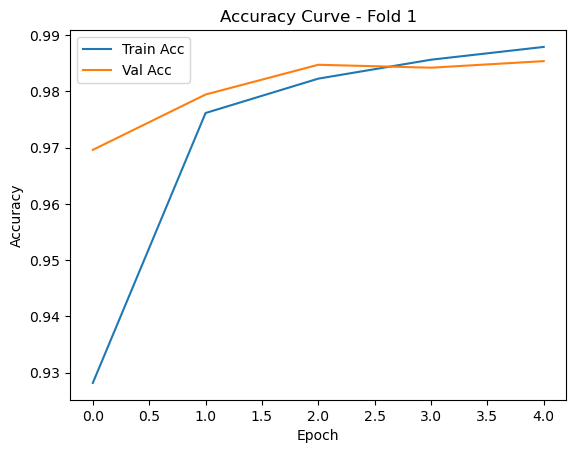

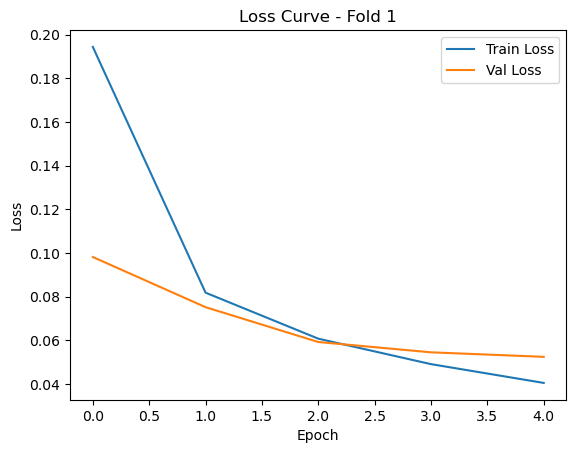

Fold 1 Metrics:
Accuracy: 0.9854, Precision: 0.9872, Recall: 0.9821, F1: 0.9847


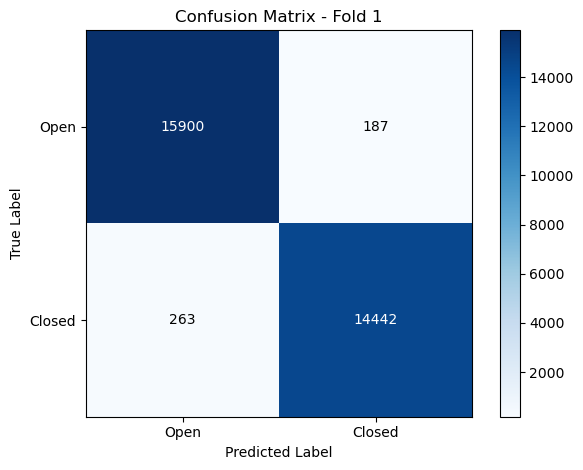

Overall ROC AUC: 0.9975693941648931


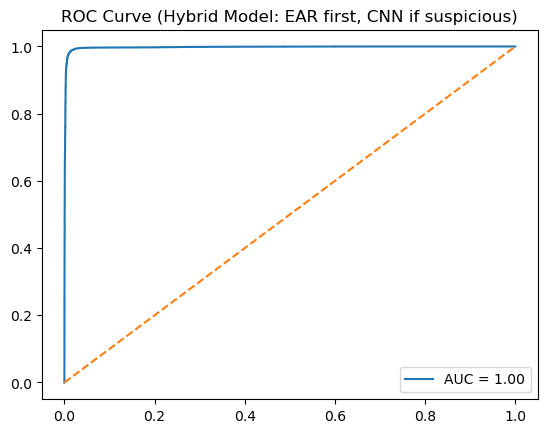


========== FOLD 2 ==========
Fold 2 | Epoch 1/5 | Train Loss: 0.2134, Train Acc: 0.9222 | Val Loss: 0.1152, Val Acc: 0.9675
Fold 2 | Epoch 2/5 | Train Loss: 0.0924, Train Acc: 0.9735 | Val Loss: 0.0729, Val Acc: 0.9797
Fold 2 | Epoch 3/5 | Train Loss: 0.0659, Train Acc: 0.9811 | Val Loss: 0.0613, Val Acc: 0.9838
Fold 2 | Epoch 4/5 | Train Loss: 0.0532, Train Acc: 0.9846 | Val Loss: 0.0627, Val Acc: 0.9832
Fold 2 | Epoch 5/5 | Train Loss: 0.0451, Train Acc: 0.9869 | Val Loss: 0.0512, Val Acc: 0.9850


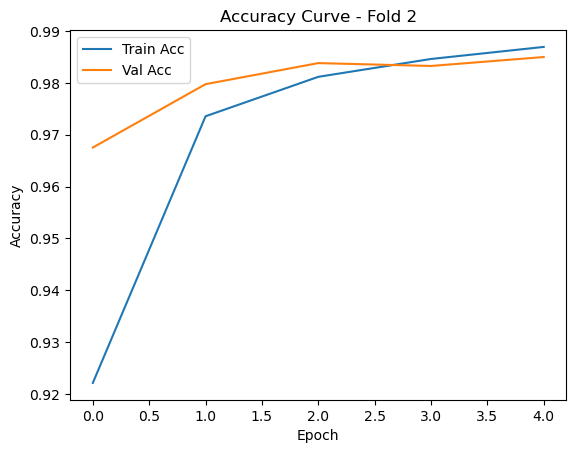

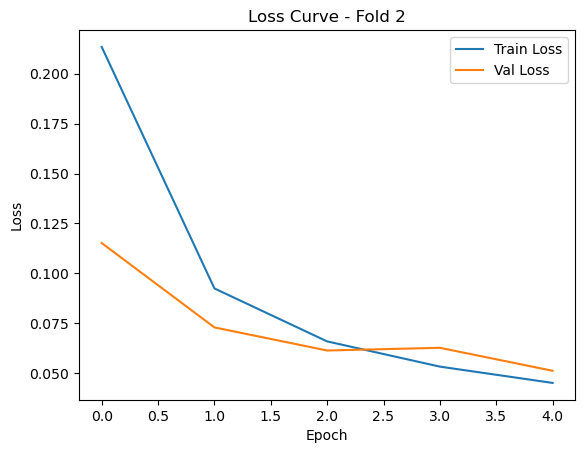

Fold 2 Metrics:
Accuracy: 0.9850, Precision: 0.9826, Recall: 0.9856, F1: 0.9841


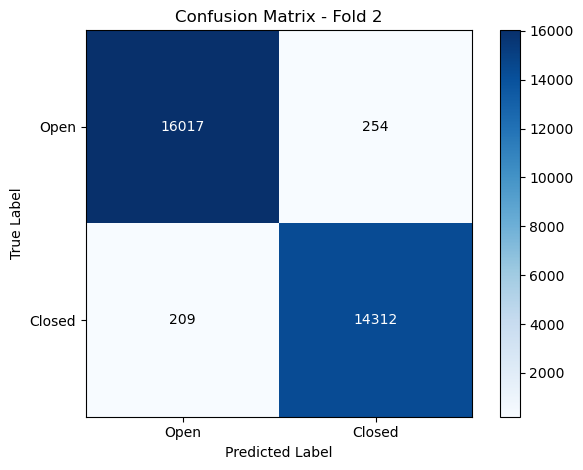

Overall ROC AUC: 0.9976744513675653


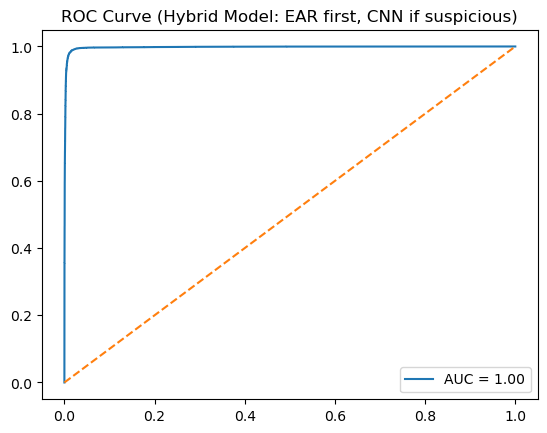


========== FOLD 3 ==========
Fold 3 | Epoch 1/5 | Train Loss: 0.2003, Train Acc: 0.9247 | Val Loss: 0.1046, Val Acc: 0.9700
Fold 3 | Epoch 2/5 | Train Loss: 0.0838, Train Acc: 0.9758 | Val Loss: 0.0796, Val Acc: 0.9768
Fold 3 | Epoch 3/5 | Train Loss: 0.0600, Train Acc: 0.9828 | Val Loss: 0.0836, Val Acc: 0.9765
Fold 3 | Epoch 4/5 | Train Loss: 0.0486, Train Acc: 0.9859 | Val Loss: 0.0487, Val Acc: 0.9856
Fold 3 | Epoch 5/5 | Train Loss: 0.0400, Train Acc: 0.9882 | Val Loss: 0.0507, Val Acc: 0.9866


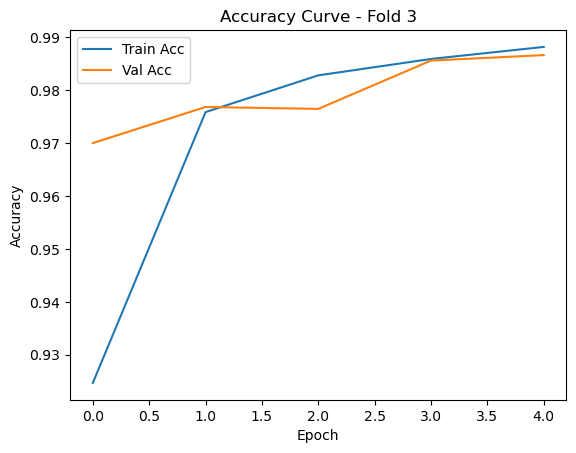

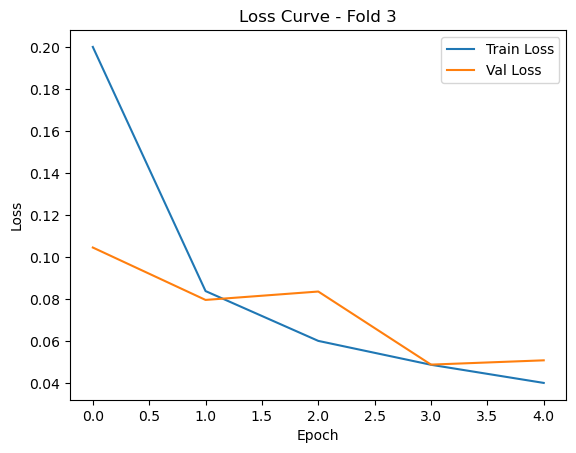

Fold 3 Metrics:
Accuracy: 0.9866, Precision: 0.9907, Recall: 0.9811, F1: 0.9859


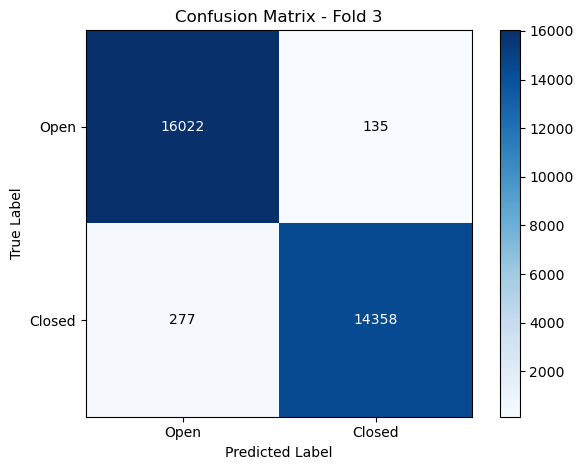

Overall ROC AUC: 0.9978015085710028


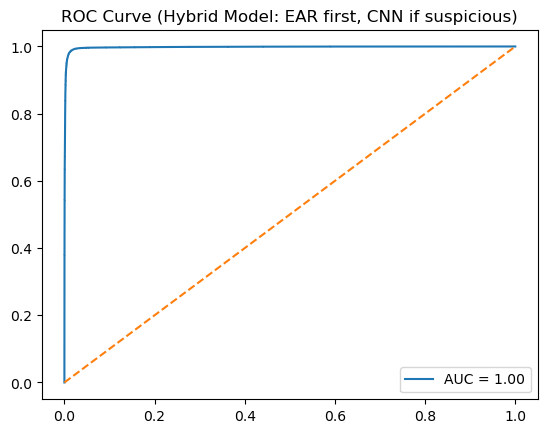


========== FOLD 4 ==========
Fold 4 | Epoch 1/5 | Train Loss: 0.1973, Train Acc: 0.9272 | Val Loss: 0.1074, Val Acc: 0.9663
Fold 4 | Epoch 2/5 | Train Loss: 0.0867, Train Acc: 0.9742 | Val Loss: 0.0664, Val Acc: 0.9793
Fold 4 | Epoch 3/5 | Train Loss: 0.0631, Train Acc: 0.9818 | Val Loss: 0.0512, Val Acc: 0.9861
Fold 4 | Epoch 4/5 | Train Loss: 0.0517, Train Acc: 0.9847 | Val Loss: 0.0507, Val Acc: 0.9850
Fold 4 | Epoch 5/5 | Train Loss: 0.0421, Train Acc: 0.9874 | Val Loss: 0.0552, Val Acc: 0.9833


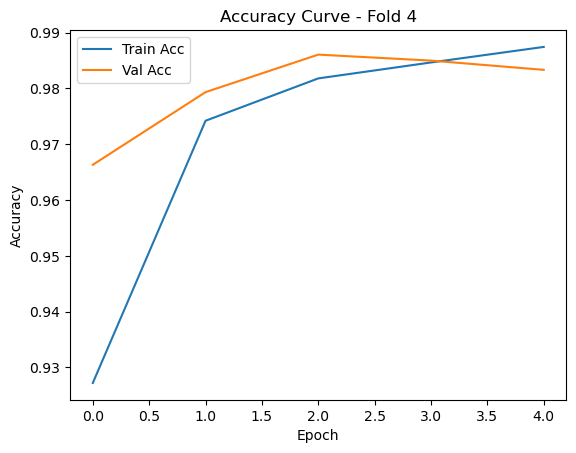

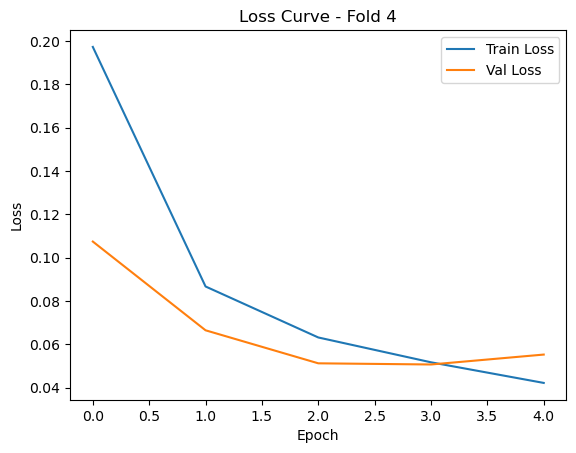

Fold 4 Metrics:
Accuracy: 0.9861, Precision: 0.9821, Recall: 0.9884, F1: 0.9853


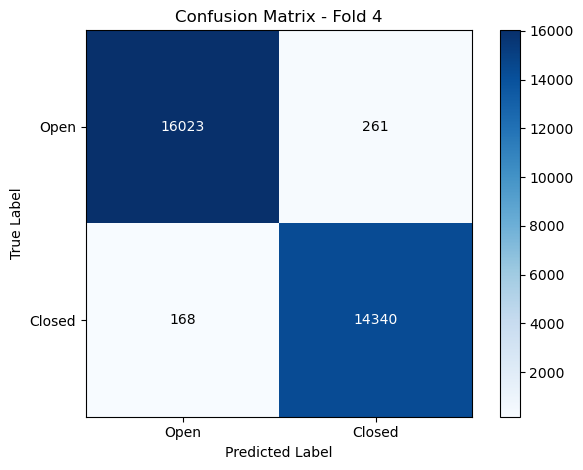

Overall ROC AUC: 0.9977047499498586


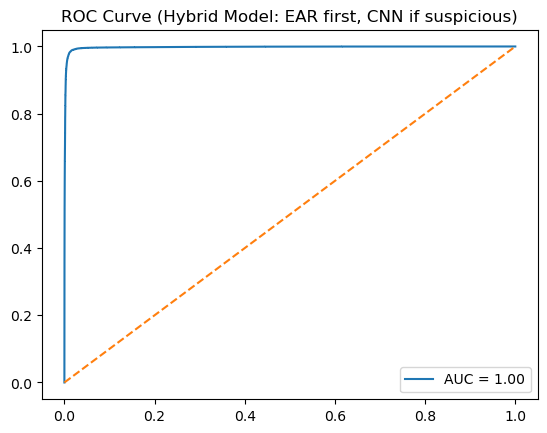


========== FOLD 5 ==========
Fold 5 | Epoch 1/5 | Train Loss: 0.2102, Train Acc: 0.9218 | Val Loss: 0.1149, Val Acc: 0.9665
Fold 5 | Epoch 2/5 | Train Loss: 0.0914, Train Acc: 0.9727 | Val Loss: 0.0873, Val Acc: 0.9739
Fold 5 | Epoch 3/5 | Train Loss: 0.0655, Train Acc: 0.9808 | Val Loss: 0.0586, Val Acc: 0.9834
Fold 5 | Epoch 4/5 | Train Loss: 0.0547, Train Acc: 0.9834 | Val Loss: 0.0618, Val Acc: 0.9836
Fold 5 | Epoch 5/5 | Train Loss: 0.0459, Train Acc: 0.9863 | Val Loss: 0.0510, Val Acc: 0.9849


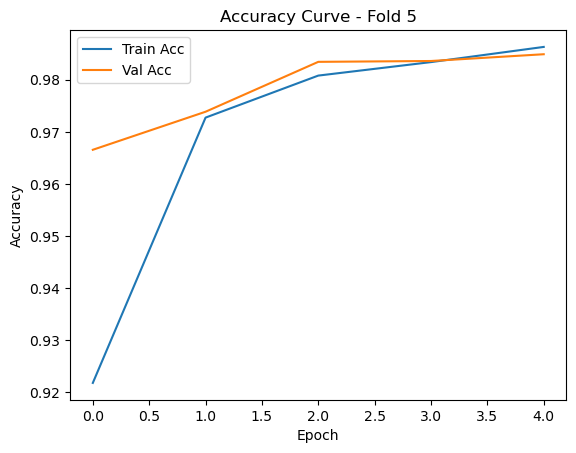

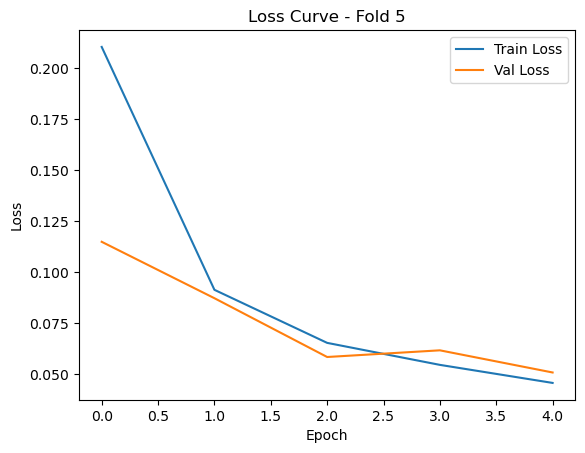

Fold 5 Metrics:
Accuracy: 0.9849, Precision: 0.9793, Recall: 0.9893, F1: 0.9843


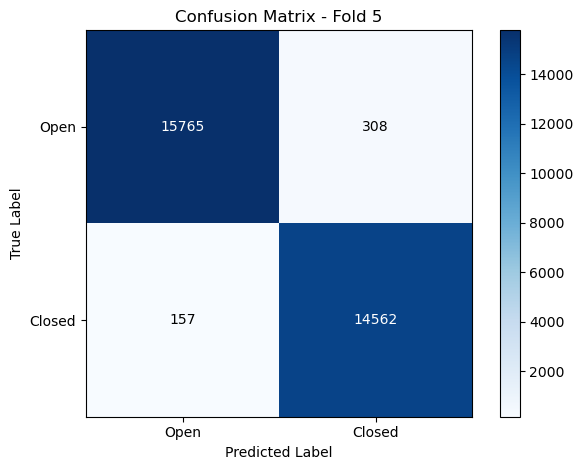

Overall ROC AUC: 0.9976681372951369


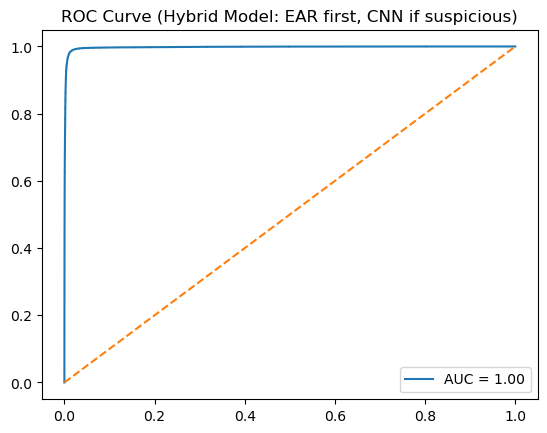

In [2]:
# =========================================================
# IMPORTS
# =========================================================
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import dlib
from scipy.spatial import distance as dist
from PIL import Image

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# DATASET
# =========================================================
class EyeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images, self.labels = [], []
        self.transform = transform
        for label, cls in enumerate(["open", "close"]):
            path = os.path.join(root_dir, cls)
            for img in os.listdir(path):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(path, img))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], 0)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# =========================================================
# MODEL
# =========================================================
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 2)
        )
    def forward(self, x):
        return self.model(x)

# =========================================================
# TRANSFORM
# =========================================================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# =========================================================
# EAR SETUP
# =========================================================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

def eye_aspect_ratio(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def compute_ear(gray):
    faces = detector(gray, 0)
    if len(faces) == 0:
        return None
    shape = predictor(gray, faces[0])
    pts = np.array([[p.x, p.y] for p in shape.parts()])
    left = eye_aspect_ratio(pts[42:48])
    right = eye_aspect_ratio(pts[36:42])
    return (left + right) / 2.0

LOW_EAR = 0.20
HIGH_EAR = 0.30

# =========================================================
# DATA
# =========================================================
DATASET_PATH = "C:/Users/Lenovo/Desktop/Image/Image"
dataset = EyeDataset(DATASET_PATH, transform=transform)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# STORAGE
# =========================================================
all_true, all_score = [], []
fold_metrics = []

# =========================================================
# K-FOLD LOOP
# =========================================================
for fold, (train_idx, test_idx) in enumerate(kf.split(dataset)):
    print(f"\n========== FOLD {fold+1} ==========")

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=32, shuffle=True)
    test_loader = DataLoader(Subset(dataset, test_idx), batch_size=32, shuffle=False)

    model = EyeCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # =========================
    # TRAINING
    # =========================
    for epoch in range(5):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss /= len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(test_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_model_fold{fold+1}.pth")

        print(f"Fold {fold+1} | Epoch {epoch+1}/5 | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # =========================
    # TRAINING CURVES
    # =========================
    plt.figure()
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.title(f"Accuracy Curve - Fold {fold+1}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title(f"Loss Curve - Fold {fold+1}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # =========================
    # TESTING (EAR first, CNN if suspicious)
    # =========================
    model.load_state_dict(torch.load(f"best_model_fold{fold+1}.pth"))
    model.eval()
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)

            for i in range(len(imgs)):
                img = imgs[i].cpu().numpy().squeeze()
                img = (img * 255).astype(np.uint8)
                ear = compute_ear(img)

                if ear is not None:
                    if ear < LOW_EAR:
                        final_pred = 1
                    elif ear > HIGH_EAR:
                        final_pred = 0
                    else:
                        final_pred = torch.argmax(outputs[i]).item()
                else:
                    final_pred = torch.argmax(outputs[i]).item()

                pos_score = probs[i][1].item()
                y_true.append(labels[i].item())
                y_pred.append(final_pred)
                y_score.append(pos_score)

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="binary")
    rec = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    print(f"Fold {fold+1} Metrics:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    fold_metrics.append((acc, prec, rec, f1))

    # Confusion Matrix plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Fold {fold+1}")
    plt.colorbar()
    classes = ["Open", "Closed"]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    # Extend global storage for ROC across folds
    all_true.extend(y_true)
    all_score.extend(y_score)

    # ROC
    fpr, tpr, _ = roc_curve(all_true, all_score, pos_label=1)
    roc_auc = auc(fpr, tpr)

    print("Overall ROC AUC:", roc_auc)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],"--")
    plt.legend()
    plt.title("ROC Curve (Hybrid Model: EAR first, CNN if suspicious)")
    plt.show()

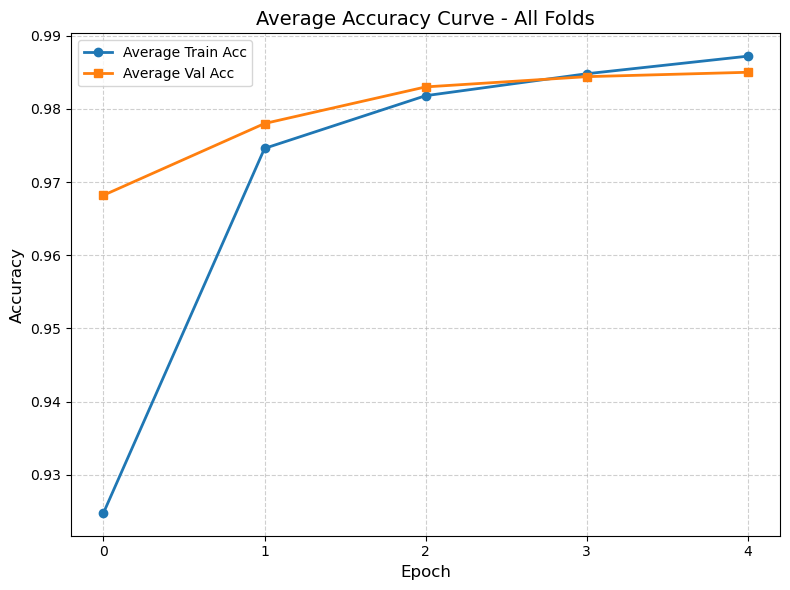

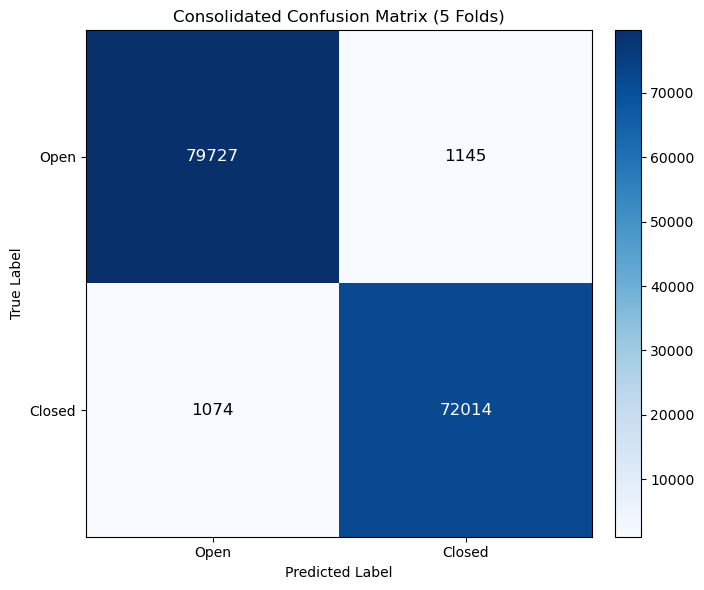

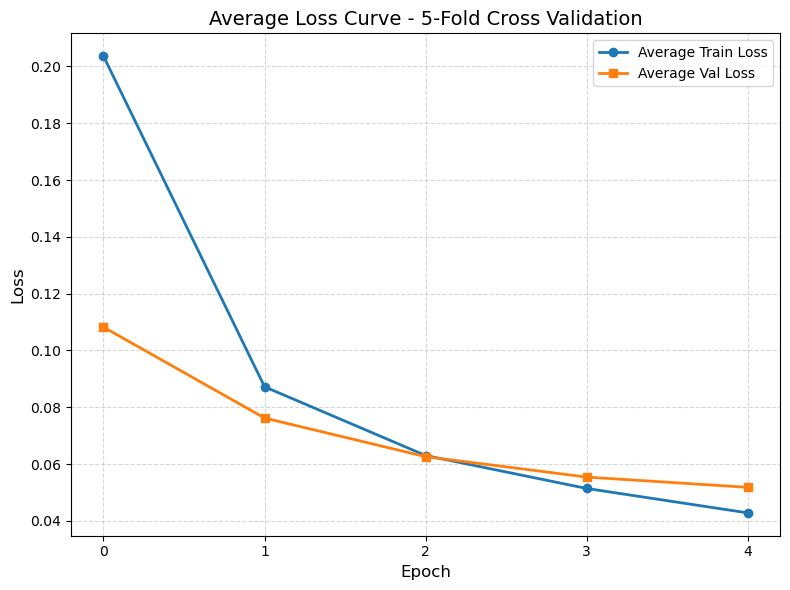

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Epochs 0 to 4
epochs = np.arange(5)

# Accuracy data extracted from your 5 folds (Approximate values)
# Rows = Folds, Columns = Epochs
train_acc_folds = np.array([
    [0.928, 0.976, 0.982, 0.985, 0.988], # Fold 1
    [0.922, 0.974, 0.981, 0.984, 0.987], # Fold 2
    [0.925, 0.976, 0.983, 0.986, 0.988], # Fold 3
    [0.927, 0.974, 0.982, 0.985, 0.987], # Fold 4
    [0.922, 0.973, 0.981, 0.984, 0.986]  # Fold 5
])

val_acc_folds = np.array([
    [0.970, 0.980, 0.985, 0.984, 0.985], # Fold 1
    [0.968, 0.980, 0.984, 0.983, 0.985], # Fold 2
    [0.970, 0.977, 0.977, 0.986, 0.987], # Fold 3
    [0.966, 0.979, 0.986, 0.985, 0.983], # Fold 4
    [0.967, 0.974, 0.983, 0.984, 0.985]  # Fold 5
])

# Calculate the mean across the folds (axis 0)
avg_train_acc = np.mean(train_acc_folds, axis=0)
avg_val_acc = np.mean(val_acc_folds, axis=0)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(epochs, avg_train_acc, label='Average Train Acc', marker='o', linewidth=2)
plt.plot(epochs, avg_val_acc, label='Average Val Acc', marker='s', linewidth=2)

# Formatting to match the "nature" of your original plots
plt.title('Average Accuracy Curve - All Folds', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


# Labels for your classes
labels = ['Open', 'Closed']

# Data extracted from your 5 uploaded Confusion Matrices
# Format: [[True Open/Pred Open, True Open/Pred Closed], [True Closed/Pred Open, True Closed/Pred Closed]]
fold1 = np.array([[15900, 187], [263, 14442]])
fold2 = np.array([[16017, 254], [209, 14312]])
fold3 = np.array([[16022, 135], [277, 14358]])
fold4 = np.array([[16023, 261], [168, 14340]])
fold5 = np.array([[15765, 308], [157, 14562]])

# Summing all folds to get the total performance
combined_cm = fold1 + fold2 + fold3 + fold4 + fold5

# Plotting the matrix using Matplotlib's imshow
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(combined_cm, interpolation='nearest', cmap=plt.cm.Blues)

# Adding the colorbar
plt.colorbar(im, fraction=0.046, pad=0.04)

# Setting labels
ax.set(xticks=np.arange(combined_cm.shape[1]),
       yticks=np.arange(combined_cm.shape[0]),
       xticklabels=labels, yticklabels=labels,
       title='Consolidated Confusion Matrix (5 Folds)',
       ylabel='True Label',
       xlabel='Predicted Label')

# Looping over data dimensions and creating text annotations
# This replaces the 'annot=True' feature of Seaborn
thresh = combined_cm.max() / 2.
for i in range(combined_cm.shape[0]):
    for j in range(combined_cm.shape[1]):
        ax.text(j, i, format(combined_cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if combined_cm[i, j] > thresh else "black",
                fontsize=12)

plt.tight_layout()
plt.show()



# Epochs 0 to 4
epochs = np.arange(5)

# Loss data extracted from your 5 folds (Approximate values)
# Rows = Folds, Columns = Epochs
train_loss_folds = np.array([
    [0.195, 0.082, 0.061, 0.049, 0.041], # Fold 1
    [0.215, 0.092, 0.066, 0.053, 0.045], # Fold 2
    [0.200, 0.084, 0.060, 0.048, 0.040], # Fold 3
    [0.198, 0.087, 0.063, 0.052, 0.042], # Fold 4
    [0.210, 0.091, 0.065, 0.055, 0.046]  # Fold 5
])

val_loss_folds = np.array([
    [0.098, 0.075, 0.059, 0.054, 0.052], # Fold 1
    [0.115, 0.073, 0.061, 0.062, 0.051], # Fold 2
    [0.105, 0.080, 0.084, 0.049, 0.051], # Fold 3
    [0.108, 0.066, 0.051, 0.050, 0.055], # Fold 4
    [0.115, 0.087, 0.058, 0.062, 0.050]  # Fold 5
])

# Calculate the mean across the folds
avg_train_loss = np.mean(train_loss_folds, axis=0)
avg_val_loss = np.mean(val_loss_folds, axis=0)

# Plotting the Average Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, avg_train_loss, label='Average Train Loss', color='tab:blue', linewidth=2, marker='o')
plt.plot(epochs, avg_val_loss, label='Average Val Loss', color='tab:orange', linewidth=2, marker='s')

# Academic Formatting
plt.title('Average Loss Curve - 5-Fold Cross Validation', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()